# Multiclass classifier on IRIS **dataset**

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import label_binarize

In [7]:
# Load the Iris dataset
# classidication (supervised): the network has to identify which flower is
iris = load_iris()
print(iris.feature_names)
print(iris.target_names)
X = iris.data  # Features
y = iris.target  # Labels

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [8]:
# One-hot encode the labels: use (1,0,0), (0,1,0), (0,0,1) (convert the labels)
y = to_categorical(y)

In [9]:
# Split data into training (60%), test (20%), and validation (20%), stratify keep the proportion between the 3 species
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [11]:
# Check the shapes of the datasets (number of events, features considered)
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Validation set shape: X_val={X_val.shape}, y_val={y_val.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(90, 4), y_train=(90, 3)
Validation set shape: X_val=(30, 4), y_val=(30, 3)
Test set shape: X_test=(30, 4), y_test=(30, 3)


In [12]:
#remove not needed datasets to reduce memory consumption
del X_temp, y_temp, X, y

In [13]:
# Define the neural network model
model = Sequential()

In [14]:
# Add layers: in this case 2 hidden layers with relu activation
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))  # Output layer with 3 exits interpretabili come probabilità assegnate alle tre specie

In [16]:
# Compile the model (optimazer is the algorith that updates the weight, loss evaluate the difference between the label and the prediction, accuracy tells you how good was the prediction)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.3333 - loss: 1.7404 - val_accuracy: 0.3333 - val_loss: 1.6587
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3333 - loss: 1.6404 - val_accuracy: 0.3333 - val_loss: 1.5687
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3333 - loss: 1.5571 - val_accuracy: 0.3333 - val_loss: 1.4814
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3333 - loss: 1.4732 - val_accuracy: 0.3333 - val_loss: 1.3989
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3333 - loss: 1.3884 - val_accuracy: 0.3333 - val_loss: 1.3221
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3333 - loss: 1.3143 - val_accuracy: 0.3333 - val_loss: 1.2506
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3333 - loss: 1.2458 - val_accuracy: 0.3333 - val_loss: 1.1854
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3333 - loss: 1.1816 - val_accuracy: 0.3333 - val_loss

In [20]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.4226
Test Loss: 0.4226
Test Accuracy: 1.0000


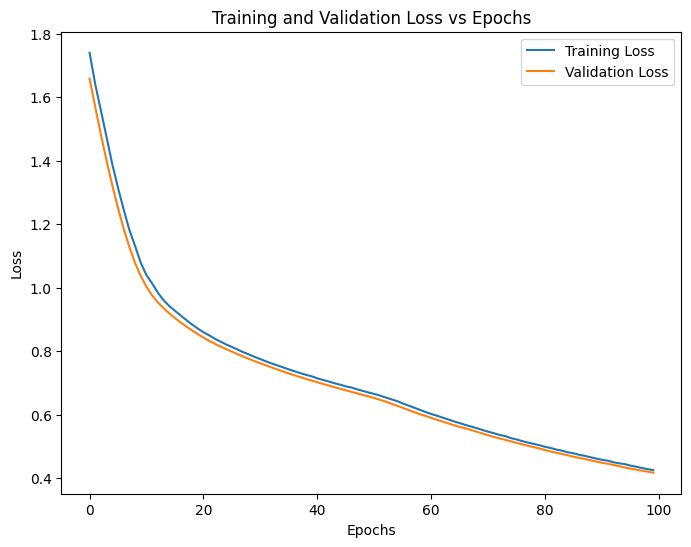

In [18]:
# Plot training & validation loss vs epochs
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

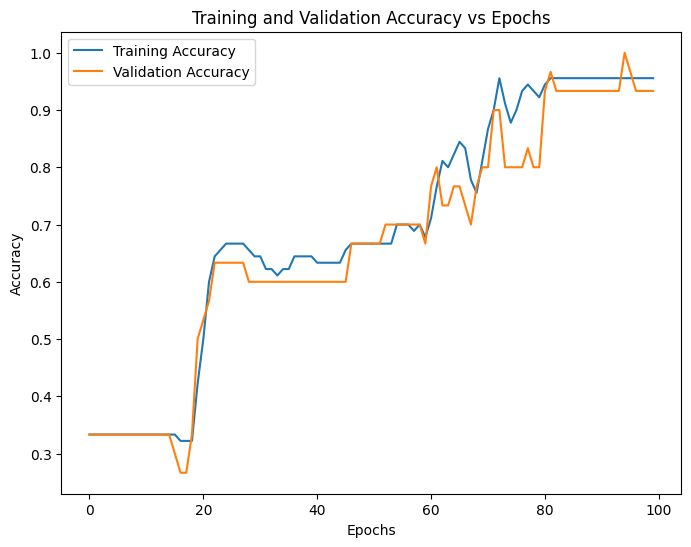

In [19]:
# Plot training & validation loss vs epochs
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.4065
Test Loss: 0.4065
Test Accuracy: 1.0000


3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


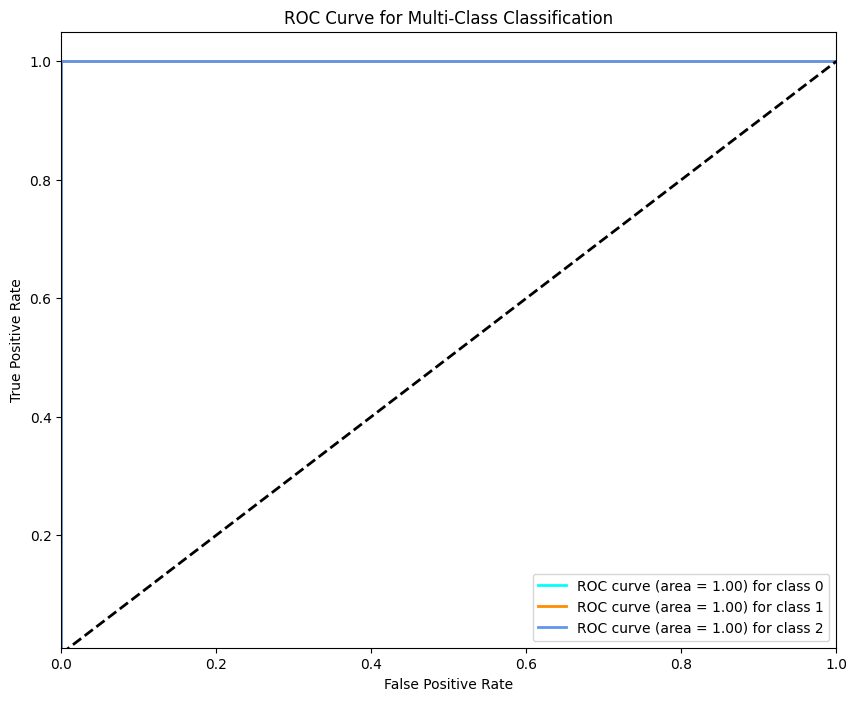

In [21]:
# ROC curve for the test dataset (One-vs-Rest)
#print(y_test.shape)
n_classes = y_test.shape[1]
print(n_classes)

# Predict probabilities on the test set
y_score = model.predict(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i]) # auc: area under the curve

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve (area = {roc_auc[i]:.2f}) for class {i}')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.01, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class Classification')
plt.legend(loc="lower right")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


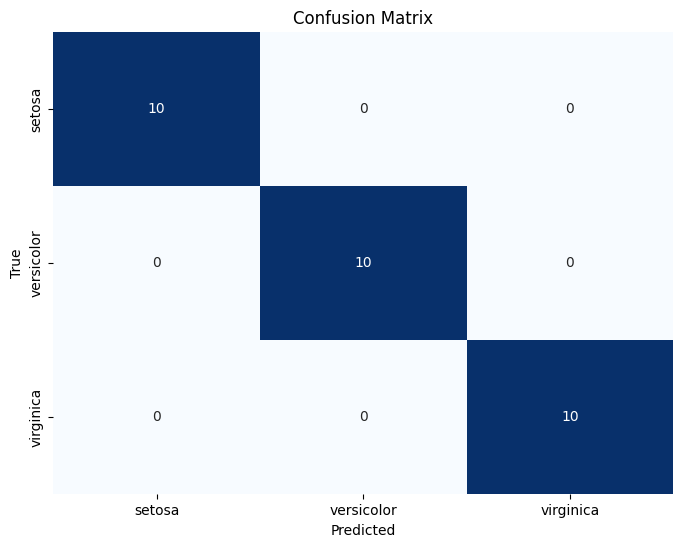

In [ ]:
# Confusion matrix for the test dataset
y_pred = np.argmax(model.predict(X_test), axis=1)  # Convert probabilities to class labels (0, 1, or 2)
y_true = np.argmax(y_test, axis=1) #Converts the true labels from one-hot encoding to class indices. For example, `[0, 1, 0]` becomes `1`.

cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix using seaborn heatmap (annot write the counts in the cellars, fmt="d" formats them as integers)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# **Binary classifier on TITANIC dataset:**

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# Load Titanic dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic_data = pd.read_csv(url)

In [ ]:
# Display the first few rows of the dataset
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print(titanic_data)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [ ]:
# some standard processing
# Fill missing values (NaN) in 'Age' with the median age
titanic_data['Age'] = titanic_data['Age'].fillna(titanic_data['Age'].median())

# Fill missing values in 'Embarked' with the mode (most frequent value)
titanic_data['Embarked'] = titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0])

# Drop rows where 'Fare' is missing (if any)
titanic_data.dropna(subset=['Fare'], inplace=True)

# Drop unnecessary columns (PassengerId, Name, Ticket, Cabin)
titanic_data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# Convert categorical features 'Sex' and 'Embarked' to numeric using LabelEncoder
label_encoder = LabelEncoder()
titanic_data['Sex'] = label_encoder.fit_transform(titanic_data['Sex'])
titanic_data['Embarked'] = label_encoder.fit_transform(titanic_data['Embarked'])

In [ ]:
# Define features (X) and target (y)
X = titanic_data.drop(columns=['Survived'])
y = titanic_data['Survived']
print(X.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [ ]:
# Split the datasets into training (60%), validation (20%), and test (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Fit the scaler on training data only, then apply it to all three sets
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
#remove not needed datasets to reduce memory consumption
del X_temp, y_temp, X, y

In [ ]:
# Check the shapes of the datasets
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Validation set shape: X_val={X_val.shape}, y_val={y_val.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(534, 7), y_train=(534,)
Validation set shape: X_val=(178, 7), y_val=(178,)
Test set shape: X_test=(179, 7), y_test=(179,)


In [ ]:
# Define the neural network model

In [ ]:
# Add layers

In [ ]:
# Compile the model

In [ ]:
# Train the model

In [ ]:
# Evaluate the model on the test set

In [ ]:
# Plot training & validation accuracy vs epochs

# Plot training & validation loss vs epochs

In [ ]:
# Generate predictions for the test set

In [ ]:
# Plot ROC curve

In [ ]:
# Compute and plot confusion matrix